<a href="https://colab.research.google.com/github/tamyriscabral/lia1_2026_2/blob/main/Resolu%C3%A7%C3%A3o_Desafio_Matplotlib_e_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Visualização de Dados e Estudo de Caso

## 💪 **Desafio Final:**
Escolha um dataset do Kaggle e realize uma análise completa:
1. 🧹 **Limpeza dos dados**
2. 📊 **Análise exploratória**
3. 📈 **Visualizações informativas**
4. 🔍 **Identificação de insights**
5. 📋 **Conclusões e recomendações**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


url = 'https://raw.githubusercontent.com/tamyriscabral/ArquivosColab/main/automobile.csv'
automobile = pd.read_csv(url)

print("Dimensões do dataset:", automobile.shape)

print("\nColunas:")
print(automobile.columns.tolist())

print("\nPrimeiras linhas:")
automobile.head()

Dimensões do dataset: (202, 26)

Colunas:
['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

Primeiras linhas:


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


###1. Limpeza dos dados

In [ ]:
print("Valores ausentes:")
print(automobile.isnull().sum())

Valores ausentes:
symboling             0
normalized-losses    37
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  0
stroke                0
compression-ratio     0
horsepower            0
peak-rpm              0
city-mpg              0
highway-mpg           0
price                 0
dtype: int64


In [ ]:
# Tratamento dos valores ausentes

automobile['normalized-losses'] = automobile['normalized-losses'].fillna(
    automobile['normalized-losses'].median()
)

automobile['num-of-doors'] = automobile['num-of-doors'].fillna(
    automobile['num-of-doors'].mode()[0]
)

print("Valores ausentes após a limpeza:")
print(automobile.isnull().sum())

Valores ausentes após a limpeza:
symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


In [ ]:
colunas_numericas = [
    'normalized-losses',
    'wheel-base',
    'length',
    'width',
    'height',
    'curb-weight',
    'engine-size',
    'bore',
    'stroke',
    'compression-ratio',
    'horsepower',
    'peak-rpm',
    'city-mpg',
    'highway-mpg',
    'price'
]

for coluna in colunas_numericas:
    automobile[coluna] = pd.to_numeric(
        automobile[coluna],
        errors='coerce'
    )

In [ ]:
print("Número de duplicatas:",  automobile.duplicated().sum())

automobile = automobile.drop_duplicates()

Número de duplicatas: 1


###2. Análise exploratória

In [ ]:
automobile.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,197.000000,201.000000,199.000000,199.000000,201.000000,201.000000,201.000000
mean,0.840796,120.711443,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330711,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567,13207.129353
std,1.254802,32.111623,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.270793,0.319256,4.004965,37.553843,480.521824,6.423220,6.815150,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,137.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


In [ ]:
print("Preço médio:", automobile['price'].mean())
print("Preço mínimo:", automobile['price'].min())
print("Preço máximo:", automobile['price'].max())

Preço médio: 13207.129353233831
Preço mínimo: 5118
Preço máximo: 45400


In [ ]:
print("Qual fabricante possui os carros mais caros, em média?")

preco_marca = automobile.groupby('make')['price'].mean().sort_values(
    ascending=False
)

print(preco_marca.head(1))

Qual fabricante possui os carros mais caros, em média?
make
jaguar    34600.0
Name: price, dtype: float64


In [ ]:
print("Qual tipo de carroceria possui maior preço médio?")

preco_carroceria = automobile.groupby('body-style')['price'].mean().sort_values(
    ascending=False
)

print(preco_carroceria.head(1))

Qual tipo de carroceria possui maior preço médio?
body-style
hardtop    22208.5
Name: price, dtype: float64


###3. Visualizações informativas

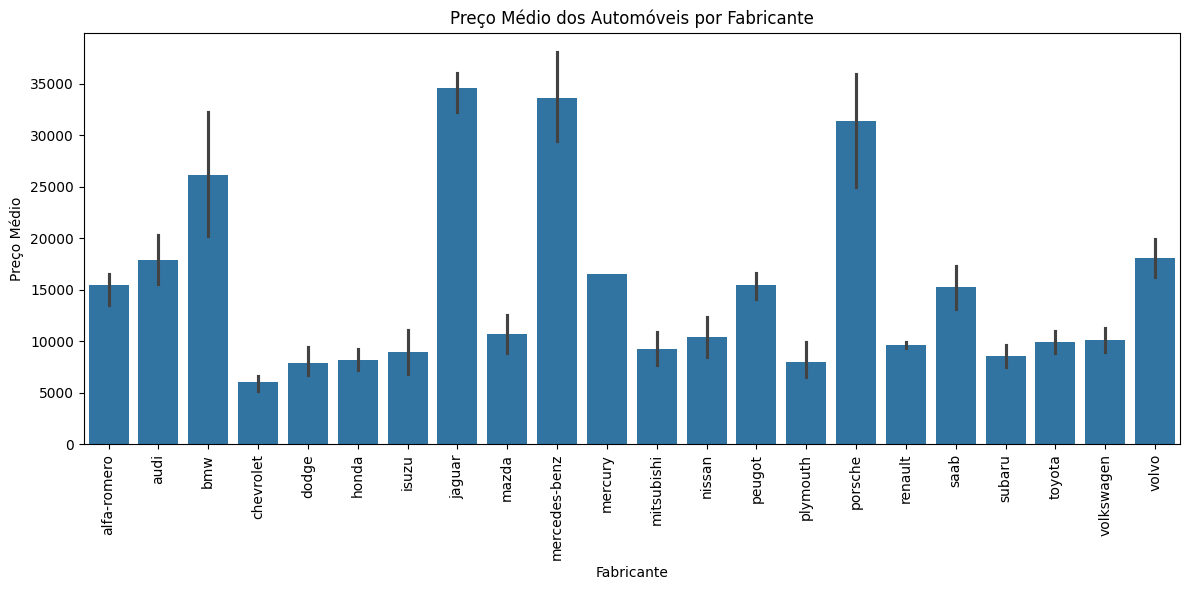

In [ ]:
#Preço médio por fabricante
plt.figure(figsize=(12, 6))

sns.barplot(
    x='make',
    y='price',
    data=automobile
)

plt.title('Preço Médio dos Automóveis por Fabricante')
plt.xlabel('Fabricante')
plt.ylabel('Preço Médio')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

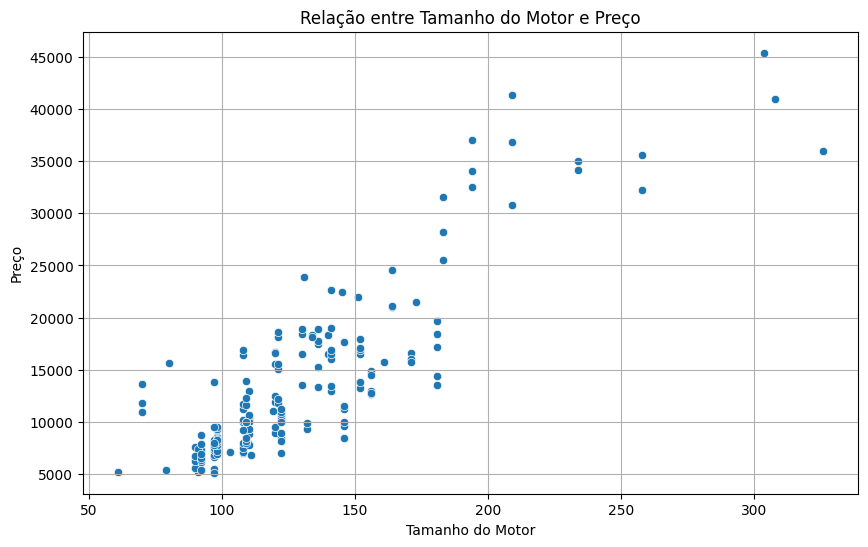

In [ ]:
#Relação entre tamanho do motor e preço
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='engine-size',
    y='price',
    data=automobile
)

plt.title('Relação entre Tamanho do Motor e Preço')
plt.xlabel('Tamanho do Motor')
plt.ylabel('Preço')

plt.grid(True)

plt.show()

In [ ]:
correlacao = automobile['engine-size'].corr(
    automobile['price']
)

print(f"Correlação entre tamanho do motor e preço: {correlacao:.3f}")

Correlação entre tamanho do motor e preço: 0.872


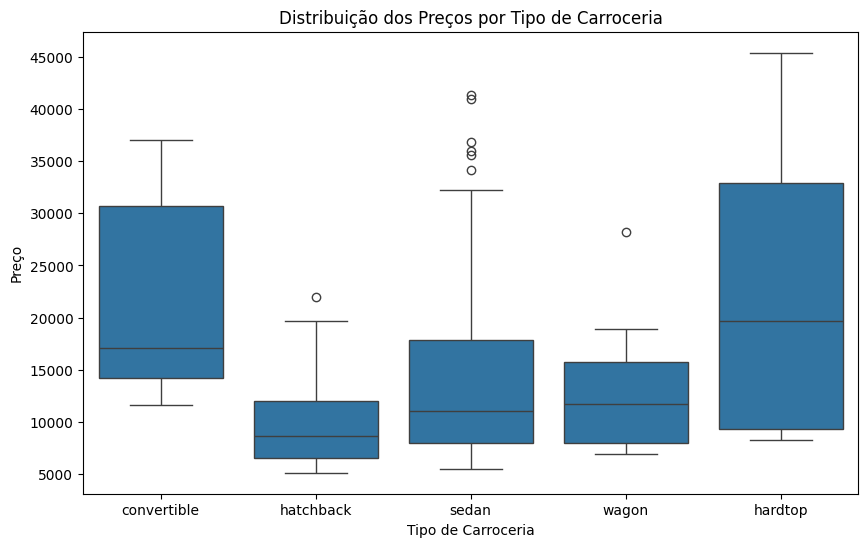

In [ ]:
#Preço por tipo de carroceria
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='body-style',
    y='price',
    data=automobile
)

plt.title('Distribuição dos Preços por Tipo de Carroceria')
plt.xlabel('Tipo de Carroceria')
plt.ylabel('Preço')

plt.show()

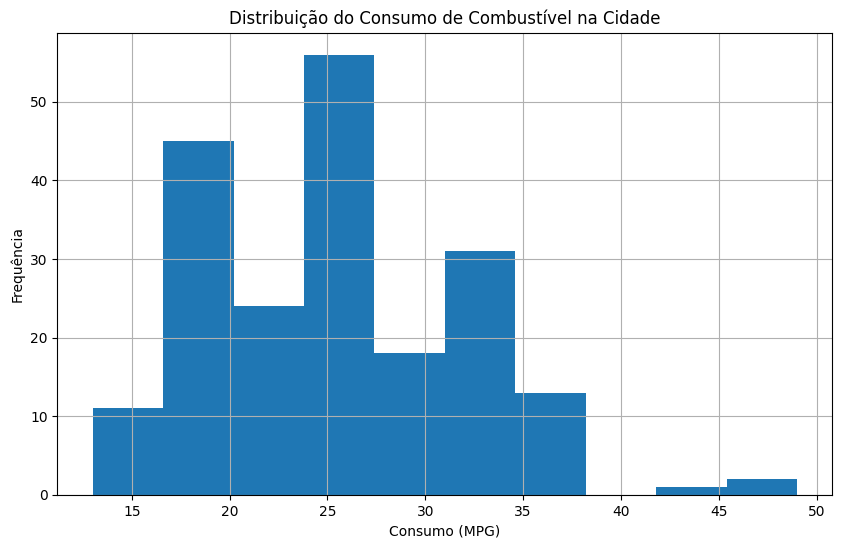

In [ ]:
#Consumo de Combustível
plt.figure(figsize=(10, 6))

plt.hist(
    automobile['city-mpg'],
    bins=10
)

plt.title('Distribuição do Consumo de Combustível na Cidade')
plt.xlabel('Consumo (MPG)')
plt.ylabel('Frequência')

plt.grid(True)

plt.show()

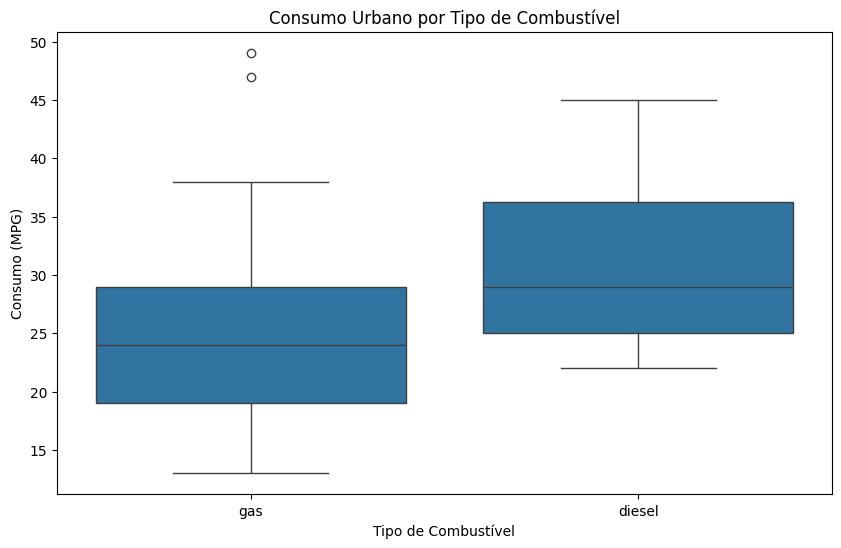

In [ ]:
#Consumo entre os tipos de combustível
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='fuel-type',
    y='city-mpg',
    data=automobile
)

plt.title('Consumo Urbano por Tipo de Combustível')
plt.xlabel('Tipo de Combustível')
plt.ylabel('Consumo (MPG)')

plt.show()

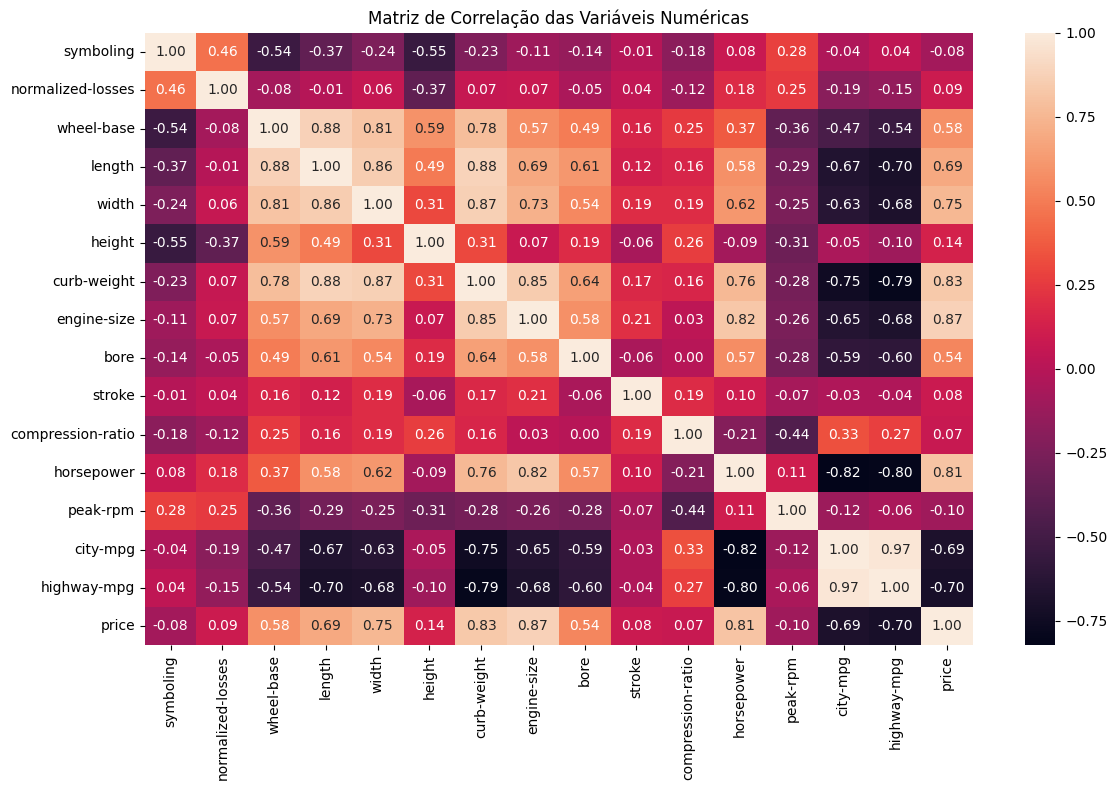

In [ ]:
#Matriz de correlação
plt.figure(figsize=(12, 8))

correlacoes = automobile.select_dtypes(
    include='number'
).corr()

sns.heatmap(
    correlacoes,
    annot=True,
    fmt='.2f'
)

plt.title('Matriz de Correlação das Variáveis Numéricas')

plt.tight_layout()
plt.show()

###Identificação de insights

In [ ]:
print("Correlação entre preço e tamanho do motor:",
      automobile['price'].corr(automobile['engine-size']))

print("Correlação entre preço e peso:",
      automobile['price'].corr(automobile['curb-weight']))

print("Correlação entre preço e potência:",
      automobile['price'].corr(automobile['horsepower']))

print("Correlação entre preço e consumo urbano:",
      automobile['price'].corr(automobile['city-mpg']))

Correlação entre preço e tamanho do motor: 0.8723351674455196
Correlação entre preço e peso: 0.8344145257702834
Correlação entre preço e potência: 0.8105330821322059
Correlação entre preço e consumo urbano: -0.686571006784468


###Conclusões

A análise do dataset Automobile mostrou que existem relações importantes entre as características dos veículos e seus preços. O tamanho do motor apresentou uma forte correlação positiva com o preço (0,872), indicando que veículos com motores maiores tendem a apresentar preços mais elevados.

O peso do veículo também apresentou forte correlação positiva com o preço (0,834). Da mesma forma, a potência do motor apresentou uma correlação positiva significativa (0,811), mostrando que veículos mais potentes tendem a possuir preços maiores.

Por outro lado, o consumo urbano apresentou correlação negativa com o preço (−0,687). Isso indica uma tendência de que veículos com maior consumo em MPG tendem a apresentar preços menores, enquanto veículos de maior preço apresentam, em geral, menor consumo em MPG.

A análise exploratória também mostrou diferenças entre os fabricantes. O Jaguar apresentou o maior preço médio, de aproximadamente 34.600, enquanto, entre os tipos de carroceria, o hardtop apresentou o maior preço médio, de aproximadamente 22.208,50. O preço dos veículos variou de 5.118 a 45.400, com média de aproximadamente 13.207.

As visualizações reforçam esses resultados. O gráfico de dispersão entre tamanho do motor e preço apresenta uma tendência crescente bastante clara, enquanto o boxplot evidencia diferenças na distribuição dos preços entre os diferentes tipos de carroceria. A matriz de correlação também permite visualizar as relações entre as variáveis numéricas do conjunto de dados.

Em conclusão, os resultados indicam que características relacionadas ao desempenho e ao porte do veículo — principalmente tamanho do motor, peso e potência — estão fortemente associadas ao preço dos automóveis. Já o consumo urbano apresenta uma relação inversa com o preço. Essas relações mostram que características técnicas dos veículos podem ser importantes para compreender as diferenças de preço observadas no dataset.